# Phase-contrast imaging of a two-component K-39 BEC

A forward model, end to end: build the cloud, build the probe, propagate the probe
through the cloud, read it out — then put a spin state on the cloud and watch an
imaging pulse write into it.

Everything here runs out of `kamo.imaging` and `kamo.spin`. The notebook is
self-contained: the only experimental input is the measured Raman/clock frequency,
from which the magnetic field follows.

**The operating point.** K-39 in a 1064 nm tweezer ($w_0 = 3\ \mu$m, $f_r = 1$ kHz),
$N = 500$ atoms, at the field where the $|1,-1\rangle \to |1,0\rangle$ splitting is
the measured 119.4639 MHz. A $\sigma^-$ D2 probe sits at the **midpoint** of the two
ground-state transitions, collected at NA 0.42 along the tweezer axis.

**Why the midpoint.** There $\delta_\downarrow = -\delta_\uparrow$ exactly. Since
$\mathrm{Im}\,\alpha$ is even in $\delta$ and $\mathrm{Re}\,\alpha$ is odd, the
optical depth is spin-blind while the refractive phase is proportional to the spin
imbalance $\xi = p_\uparrow - p_\downarrow$. Phase contrast there reads $S_z$, not
atom number.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import kamo.constants as kc
from kamo import Potassium39
from kamo.BEC_properties.variational import GaussianVariationalCloud
from kamo.imaging import ProbeBeam, Propagator, UniformMixture, Sky, readout
from kamo.imaging import plotting as iplt
from kamo.spin import SpinField, SpinGeometry, Sequence, Rotate, ImagePulse, ramsey
from kamo.spin import plotting as splt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['legend.fontsize'] = 'small'
np.set_printoptions(precision=4, suppress=True)

NA = 0.42
N_ATOMS = 500.
F_RAMAN = 119.4639e6      # measured |1,-1> -> |1,0> splitting (Ramsey fit)
TWEEZER_WAIST = 3.0e-6    # trap waist; also sets the spatial plot windows
N_WAISTS = 3.0            # every spatial panel views +-N_WAISTS x the waist

## 1. Field and scattering lengths

The clock frequency fixes the field. Note where that lands: just past the
$|1,-1\rangle$ zero crossing, where $a_{\uparrow\uparrow}$ is small **and steep** —
about $1.2\,a_0$ per gauss on a value of $11.3\,a_0$. Cloud size, peak density,
optical depth and phase all inherit that sensitivity, so treat $B$ as a calibration
input, not a constant.

In [2]:
atom = Potassium39()
B = atom.get_magnetic_field_from_ground_state_transition_frequency(
    f1=1, mf1=-1, f2=1, mf2=0, transition_frequency_Hz=F_RAMAN)
a_upup = atom.get_scattering_length(1, -1, B)
a_dndn = atom.get_scattering_length(1,  0, B)
print(f"B = {B:.4f} G")
print(f"a(|1,-1>) = {a_upup:+.2f} a0     a(|1,0>) = {a_dndn:+.2f} a0")

print("\nsensitivity of a_upup to the field calibration:")
for db in (-3., -1., 0., +1., +3.):
    print(f"  B {B+db:8.2f} G -> a_upup = {atom.get_scattering_length(1,-1,B+db):+7.2f} a0")

B = 520.5830 G
a(|1,-1>) = +11.33 a0     a(|1,0>) = -73.70 a0

sensitivity of a_upup to the field calibration:
  B   517.58 G -> a_upup =   +8.53 a0
  B   519.58 G -> a_upup =  +10.33 a0
  B   520.58 G -> a_upup =  +11.33 a0
  B   521.58 G -> a_upup =  +12.35 a0
  B   523.58 G -> a_upup =  +14.54 a0


## 2. The cloud

A Gaussian-ansatz GPE ground state. Neither limiting case applies here: the
Thomas-Fermi parameter is $\chi = Na/a_{ho} \approx 0.4$, so TF overestimates the
cloud and the ideal gas underestimates it.

The $|\downarrow\rangle$ cloud is a different story — $a$ is attractive,
so it collapses above $N \approx 100$. Everything below therefore uses the
$|\uparrow\rangle$ widths for every spin state, which holds the density
fixed so the only thing changing between cases is the polarizability. A controlled
comparison, not a prediction of what a real $|\downarrow\rangle$ cloud would do.

In [ ]:
cloud = GaussianVariationalCloud.from_tweezer(
    N=N_ATOMS, a_scattering=a_upup * kc.a0, f_radial_Hz=1.0e3, waist=TWEEZER_WAIST)
print(cloud.summary())

dn = GaussianVariationalCloud.from_tweezer(
    N=N_ATOMS, a_scattering=a_dndn * kc.a0, f_radial_Hz=1.0e3, waist=TWEEZER_WAIST)
print()
print(dn.summary())

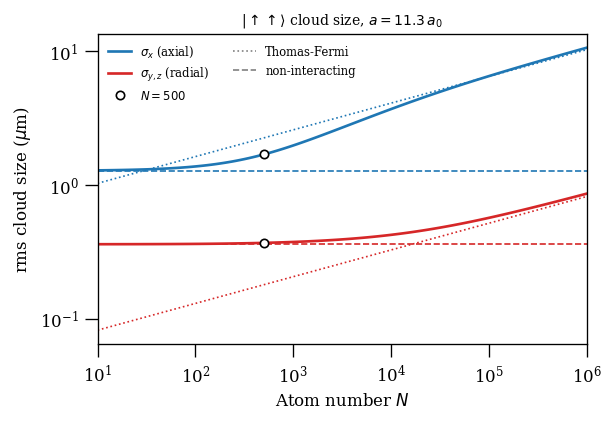

In [4]:
fig, ax = iplt.plot_cloud_size_vs_atom_number(cloud)
ax.set_title(rf"$|\uparrow\rangle$ cloud size, $a = {a_upup:.1f}\,a_0$",
             fontsize='small')
plt.show()

## 3. The probe

`ProbeBeam.from_midpoint` finds both $\sigma^-$ transitions at this field and parks
the laser between them. The resonant cross section comes from the **actual**
field-shifted transition, $\sigma_0 = 3\lambda^2/2\pi$ with $\lambda = c/f_0$.

In [5]:
probe = ProbeBeam.from_midpoint(
    atom, B_gauss=B,
    ground_up=(4, 0, 1/2, -1/2, +1/2), excited_up=(4, 1, 3/2, -3/2, +1/2),
    ground_dn=(4, 0, 1/2, -1/2, -1/2), excited_dn=(4, 1, 3/2, -3/2, -1/2))
probe = ProbeBeam.from_offresonant_saturation(probe, 0.001, which='up')
response = probe.response
print(probe.summary())

ProbeBeam  f = 391.018037 THz (+0.000 MHz from midpoint)
  |up>  f = 391.018093 THz, Delta =  -55.110 MHz -> delta =  -18.355
  |dn>  f = 391.017982 THz, Delta =  +55.110 MHz -> delta =  +18.355
  splitting S = 110.2206 MHz  (at midpoint: delta_dn = -delta_up)
  incident s0 = 0.3379, differential light shift = +55.055 kHz
  TwoLevelResponse(lambda=766.6974 nm, Gamma/2pi=6.0050 MHz, sigma0=2.806657e-13 m^2)


### The cloud is optically thin but a strong phase object

$\mathrm{Re}\,\alpha/\mathrm{Im}\,\alpha = |\delta| = 18.4$, so a purely absorptive
treatment keeps the *smaller* part by a factor of 18.

In [6]:
D, phi = response.thin_screen(cloud.peak_column_density, probe.species(xi=1.0))
dof = response.wavelength / NA**2
print(f"thin screen, all |up>:   D = {D:.4f}   phi = {phi:+.3f} rad = {phi/np.pi:.2f} pi")
print(f"equivalent thin lens f = {response.k*cloud.widths[1]**2/(2*abs(phi))*1e6:.3f} um")
print()
print("two length-scale comparisons that decide the method:")
print(f"  w_x vs k w_perp^2      : {cloud.widths[0]*1e6:.2f} vs "
      f"{response.k*cloud.widths[1]**2*1e6:.2f} um  -> ratio "
      f"{cloud.widths[0]/(response.k*cloud.widths[1]**2):.2f}"
      f"   (light diffracts INSIDE the cloud: no thin screen)")
print(f"  2 w_x vs lambda/NA^2   : {2*cloud.widths[0]*1e6:.2f} vs {dof*1e6:.2f} um"
      f"  -> ratio {2*cloud.widths[0]/dof:.2f}"
      f"   (one depth of field long: no focal plane sees it as a projection)")

thin screen, all |up>:   D = 0.4859   phi = +4.459 rad = 1.42 pi
equivalent thin lens f = 0.250 um

two length-scale comparisons that decide the method:
  w_x vs k w_perp^2      : 2.39 vs 2.23 um  -> ratio 1.07   (light diffracts INSIDE the cloud: no thin screen)
  2 w_x vs lambda/NA^2   : 4.79 vs 4.35 um  -> ratio 1.10   (one depth of field long: no focal plane sees it as a projection)


## 4. Propagation

Split-step angular spectrum: alternate an exact free-space step with the complex
polarizability of the atoms, using the local saturation parameter built from the
intensity that has actually propagated to each point — which is not the incident
one, because the cloud focuses.

In [7]:
prop = Propagator.for_cloud(response, cloud, n_grid=768, L_box=36e-6, n_slices=180)
print(prop.grid)

res = prop.propagate(UniformMixture(cloud, response, probe.species(xi=1.0)),
                     s0_incident=probe.s0_incident, record='plane')
psi = readout.refocus(res)
phi_bpm = readout.recovered_phase(psi, res.grid)
image   = readout.phase_contrast(psi, res.grid, NA=NA)
W       = readout.far_field(res)

print(f"\nrecovered phase = {phi_bpm:+.3f} rad against a thin-screen {phi:+.3f}"
      f"  -> {phi_bpm/phi*100:.0f}%")
print(f"on-axis D       = {readout.optical_depth(psi):+.3f}"
      f"   (negative: the lens piles light onto the axis faster than atoms remove it)")
print(f"peak |psi|^2    = {np.abs(psi).max()**2:.3f}")
print(f"probe concentrated to {res.s_peak/probe.s0_incident:.2f}x inside the cloud,"
      f" driving s = {res.s_peak:.3f} from an incident {probe.s0_incident:.4f}")
print(f"coherent light into NA {NA} = {readout.into_NA(W, res.grid, NA):.5f}")
print(f"wraparound check (edge power) = {res.edge_power_fraction():.2e}")

TransverseGrid(n=768, L=36.0 um, d=46.9 nm, far-field res 1.22 deg)



recovered phase = +2.608 rad against a thin-screen +4.459  -> 58%
on-axis D       = -0.506   (negative: the lens piles light onto the axis faster than atoms remove it)
peak |psi|^2    = 1.659
probe concentrated to 5.75x inside the cloud, driving s = 1.942 from an incident 0.3379
coherent light into NA 0.42 = 0.97874
wraparound check (edge power) = 2.15e-13


In [ ]:
fig, _ = iplt.plot_exit_wave(psi, res.grid, image,
    waist=TWEEZER_WAIST, n_waists=N_WAISTS,
    title=rf"BPM at the cloud plane, $N={N_ATOMS:.0f}$, recovered $\phi={phi_bpm:+.1f}$ rad"
          rf" (thin screen ${phi:+.1f}$)")
plt.show()

### Two systematics that break "signal $\propto$ column density"

1. **Depth of field.** The cloud is about one depth of field long, so even a perfect
   focused system recovers only part of the projected phase.
2. **Nonlinearity.** At several radians the textbook $I/I_0 = 1 + 2\varphi$ badly
   overstates the excursion — and goes unphysically negative.

In [9]:
ncol = cloud.column_density(res.grid.Y, res.grid.Z)
_, phi_map = response.thin_screen(ncol, probe.species(xi=1.0))
I_weak = readout.weak_phase_image(phi_map)

print(f"BPM image         I/I0 in [{image.min():.3f}, {image.max():.3f}]")
print(f"weak-phase 1+2phi I/I0 in [{I_weak.min():.2f}, {I_weak.max():.2f}]"
      + ("   (unphysical: I < 0)" if I_weak.min() < 0 else ""))
print(f"peak |I-1|: BPM {np.abs(image-1).max():.3f}  vs weak-phase "
      f"{np.abs(I_weak-1).max():.2f}"
      f"  -> linear inversion overstates by {np.abs(I_weak-1).max()/np.abs(image-1).max():.1f}x")

BPM image         I/I0 in [0.906, 7.286]
weak-phase 1+2phi I/I0 in [1.00, 9.92]
peak |I-1|: BPM 6.286  vs weak-phase 8.92  -> linear inversion overstates by 1.4x


### Validation

The propagation has to reproduce the analytic Gaussian form factor when the phase
is small, and the thin-screen phase when the cloud is short. Both, plus grid and
slice convergence, are pinned as tests (`pytest kamo/imaging/tests`); the
weak-phase check is reproduced here because it is the one that pins the propagator,
the dipole weighting and the $q_x$ handling all at once.

weak-phase BPM vs analytic 3D Gaussian form factor, over 4 decades:
  median ratio = 0.99895,  max |ratio-1| = 7.90e-03


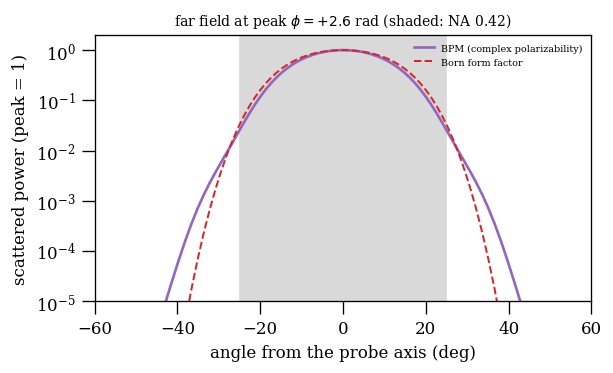

In [10]:
weak = prop.propagate(UniformMixture(cloud, response, probe.species(1.0),
                                     density_scale=0.002), saturate=False)
W_weak = readout.far_field(weak)
Born   = readout.born_far_field(weak.grid, cloud.widths, cloud.N)
m = Born > Born.max() * 1e-4
ratio = (W_weak[m] / W_weak.max()) / (Born[m] / Born.max())
print(f"weak-phase BPM vs analytic 3D Gaussian form factor, over 4 decades:")
print(f"  median ratio = {np.median(ratio):.5f},  max |ratio-1| = {np.abs(ratio-1).max():.2e}")

fig, ax = iplt.plot_far_field_cut(W, res.grid, reference=Born, NA=NA,
    title=rf"far field at peak $\phi={phi_bpm:+.1f}$ rad (shaded: NA {NA})")
plt.show()

## 5. Where the scattered light goes

The propagation carries the coherent field. The incoherent channel — and
reabsorption of photons on the way out — is separate bookkeeping.

Note the collection axis lies **in** the dipole plane, so the lens stares at the dim
lobe of $1+\cos^2\theta$. It still collects 98% of the coherent light, because that
light is confined to a narrow forward lobe.

In [11]:
sky = Sky(cloud.widths, cloud.N, response.k)
sigma_sc = response.cross_section(probe.delta_up, probe.s0_incident)
print(sky.summary(sigma_sc, NA=NA))

eta_bpm = readout.into_NA(W, res.grid, NA)
_, _, eta = sky.collected_fractions(sigma_sc, NA=NA)
print(f"\nBPM coherent into NA          {eta_bpm:.5f}")
print(f"Born coherent-only (elastic)  {eta['coh_only']:.5f}"
      f"   -> BPM/Born = {eta_bpm/eta['coh_only']:.4f}")
print("The collection efficiency survives the lensing intact; the imaging signal does not.")

Sky  N = 500, w = (2.393, 0.522, 0.522) um, sigma_sc = 8.298e-12 cm^2
  chord optical depth through the centre:
    tau_x =    0.485  -> e^-tau = 6.154e-01
    tau_y =    0.106  -> e^-tau = 8.996e-01
    tau_z =    0.106  -> e^-tau = 8.996e-01
  cloud-averaged escape fraction = 0.9661
  coherent enhancement vs incoherent = 7.75x (ceiling is N = 500)
  forward lobe 1/e half-width: 18.96 deg (y), 18.96 deg (z)
  collected into NA 0.42 along [1 0 0]:
    bare dipole (no cloud)         0.03623  (1.00x bare dipole)
    incoherent + reabsorption      0.03482  (0.96x bare dipole)
    coherent + incoherent          0.85785  (23.68x bare dipole)
    coherent + incoherent + reabs   0.85155  (23.50x bare dipole)
    coherent only (Born)           0.97966  (27.04x bare dipole)
    (an isotropic emitter would give 0.04624)

BPM coherent into NA          0.97874
Born coherent-only (elastic)  0.97966   -> BPM/Born = 0.9991
The collection efficiency survives the lensing intact; the imaging signal does

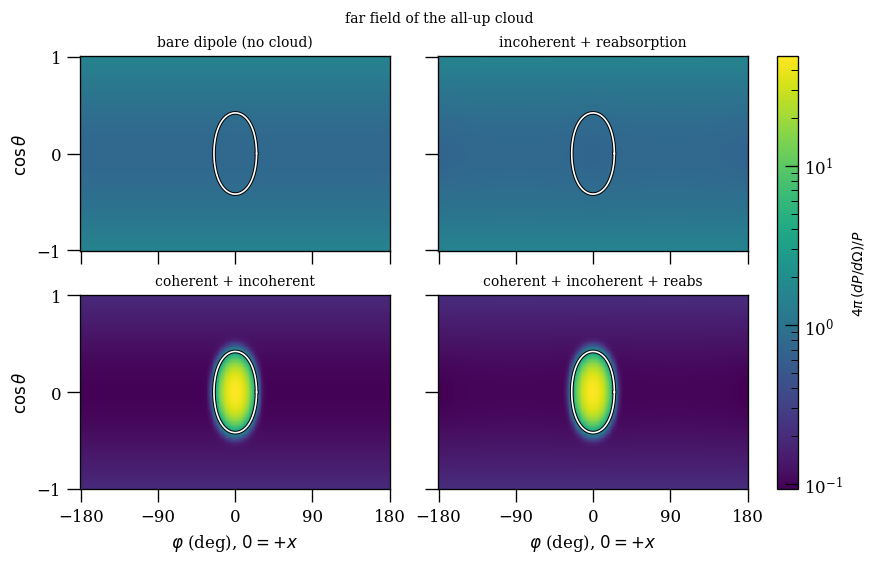

In [12]:
fig, _ = iplt.plot_sky_maps(sky, sigma_sc, NA=NA, title="far field of the all-up cloud")
plt.show()

## 5b. The $N^2$ forward mode

Driven by one probe, the atoms radiate with phases. For positions drawn from
$n(\mathbf r)/N$,

$$\left\langle \left| \sum_j e^{i\mathbf q \cdot \mathbf r_j} \right|^2 \right\rangle
= N + N(N-1)\,|f(\mathbf q)|^2, \qquad \mathbf q = k(\hat n - \hat k),$$

so the amplitude adds **in phase** only where the form factor survives. In the
forward direction $\mathbf q = 0$, $|f|^2 = 1$, and the two terms combine to $N^2$:
the amplitude goes as $N$, the power as $N^2$. Well outside the lobe $|f|^2 \to 0$
and only the $N$ incoherent photons remain.

The forward mode therefore stands above every other mode by a factor of order $N$.
That is the entire reason a dispersive measurement works here at all: the collection
axis points at the *dim* lobe of $1+\cos^2\theta$, and it still gathers 98% of the
coherent light.

In [13]:
def nhat_at(deg):
    t = np.radians(deg)
    return np.array([np.cos(t), np.sin(t), 0.0])

print("form factor along the probe axis:")
for d in (0., 1., 5., 10., 20., 40., 90.):
    print(f"  {d:5.1f} deg -> |f|^2 = {sky.form_factor_sq(nhat_at(d)):.3e}")

N_scan = np.logspace(0, 5, 41)
f2_fwd = float(sky.form_factor_sq(nhat_at(0.)))
f2_wide = float(sky.form_factor_sq(nhat_at(40.)))
P_fwd = N_scan + N_scan*(N_scan - 1)*f2_fwd
P_wide = N_scan + N_scan*(N_scan - 1)*f2_wide

print(f"\n{'N':>10} {'P(0 deg)':>13} {'P(40 deg)':>13} {'ratio':>12}")
for i in (0, 16, 24, 32, 40):
    print(f"{N_scan[i]:10.0f} {P_fwd[i]:13.4e} {P_wide[i]:13.4e} "
          f"{P_fwd[i]/P_wide[i]:12.4e}")

big = N_scan > 100
e_fwd = np.polyfit(np.log(N_scan[big]), np.log(P_fwd[big]), 1)[0]
e_wide = np.polyfit(np.log(N_scan[big]), np.log(P_wide[big]), 1)[0]
print(f"\nfitted exponents for N > 100:  forward {e_fwd:.4f}   wide-angle {e_wide:.4f}")
print(f"  -> forward power ~ N^2 (amplitude ~ N), other modes ~ N.")
print(f"  At N = {N_ATOMS:.0f} the forward mode is "
      f"{P_fwd[np.argmin(abs(N_scan-N_ATOMS))]/P_wide[np.argmin(abs(N_scan-N_ATOMS))]:.0f}x "
      f"above a wide-angle mode -- i.e. of order N.")

# Where does the coherent term stop dominating?  (N-1)|f|^2 = 1.
th = np.linspace(0, 90, 4001)
f2_th = np.array([float(sky.form_factor_sq(nhat_at(d))) for d in th])
cross = th[np.argmin(np.abs((N_ATOMS - 1)*f2_th - 1.0))]
print(f"\ncoherent term falls to the incoherent floor at {cross:.1f} deg "
      f"(NA {NA} spans {np.degrees(np.arcsin(NA)):.1f} deg)")
print("The lobe is narrowed by the LONG axis: q_x = k(cos(theta) - 1) grows with")
print("angle and w_x is the biggest width, so it closes the lobe faster than q_y.")

form factor along the probe axis:
    0.0 deg -> |f|^2 = 1.000e+00
    1.0 deg -> |f|^2 = 9.972e-01
    5.0 deg -> |f|^2 = 9.304e-01
   10.0 deg -> |f|^2 = 7.262e-01
   20.0 deg -> |f|^2 = 1.707e-01
   40.0 deg -> |f|^2 = 6.170e-07
   90.0 deg -> |f|^2 = 3.416e-88

         N      P(0 deg)     P(40 deg)        ratio
         1    1.0000e+00    1.0000e+00   1.0000e+00
       100    1.0000e+04    1.0001e+02   9.9994e+01
      1000    1.0000e+06    1.0006e+03   9.9938e+02
     10000    1.0000e+08    1.0062e+04   9.9387e+03
    100000    1.0000e+10    1.0617e+05   9.4189e+04

fitted exponents for N > 100:  forward 2.0000   wide-angle 1.0062
  -> forward power ~ N^2 (amplitude ~ N), other modes ~ N.
  At N = 500 the forward mode is 562x above a wide-angle mode -- i.e. of order N.

coherent term falls to the incoherent floor at 30.8 deg (NA 0.42 spans 24.8 deg)
The lobe is narrowed by the LONG axis: q_x = k(cos(theta) - 1) grows with
angle and w_x is the biggest width, so it closes the lobe 

### The model, not just the scaling law

The curves above are the analytic $N + N(N-1)|f|^2$. The circles are the same
forward mode extracted from the **full lensing model**: at each $N$ the cloud is
rebuilt at that atom number, the probe is propagated through it, and the
$k_\perp = 0$ far-field mode is read off. That mode is the forward-scatter
channel in the strict sense &mdash; the one component collinear with the
unscattered probe, so the one a phase-contrast measurement actually interferes
with.

The points are anchored to the analytic curve at the smallest $N$, deepest in
the weak-phase limit, where the two must agree. Everything after that is the
model departing from $N^2$ on its own &mdash; and the departure is **upward**,
because a strong lens deflects more light out of the unscattered mode than a
linear response would.

In [ ]:
# The analytic curve above is a scaling law.  This runs the FULL lensing model
# at a range of atom numbers and reads the same forward mode out of it, so the
# points carry the depth of field, the exact angular spectrum and the lens.
#
# The cloud is rebuilt at every N (widths relax as they physically would), which
# is the difference between this and the density-scale sweep two cells down:
# a real cloud at 8x the atom number is also longer and fatter.
N_bpm = np.unique(np.round(np.logspace(np.log10(5), np.log10(4000), 12)))
scan = readout.forward_mode_scan(
    response, cloud, probe.species(1.0), N_bpm,
    n_grid=512, saturate=False,          # saturation off: isolate the LENSING
    progress=lambda i, N: print(f"  N = {N:7.0f} ...", end="\r"))

f2_fwd = float(sky.form_factor_sq(nhat_at(0.)))
k0 = int(np.argmin(scan.N))
anchor = scan.N[k0] + scan.N[k0]*(scan.N[k0] - 1)*f2_fwd
ratio = (scan.forward / scan.forward[k0]) * (scan.N[k0]**2 / scan.N**2)

print(f"{'N':>7} {'w_x um':>8} {'w_perp um':>10} {'phi_thin':>9} "
      f"{'BPM fwd mode':>14} {'/N^2':>8} {'edge':>9}")
for i in range(len(scan.N)):
    print(f"{scan.N[i]:7.0f} {scan.widths[i,0]*1e6:8.3f} {scan.widths[i,1]*1e6:10.3f} "
          f"{scan.phi_thin[i]:9.3f} {scan.forward[i]:14.4e} {ratio[i]:8.3f} "
          f"{scan.edge[i]:9.2e}")

# Fit only where the thin-screen phase is still small: past a radian the lens
# is the story, not the scaling law.  (A tighter cut than this leaves too few
# points to fit at all.)
weak = scan.phi_thin < 1.0
e_bpm = np.polyfit(np.log(scan.N[weak]), np.log(scan.forward[weak]), 1)[0]
print(f"\nfitted exponent over the {weak.sum()} points with phi_thin < 1 rad: "
      f"{e_bpm:.4f}  (analytic: 2; the excess is already the lens)")
print(f"at the operating point N = {N_ATOMS:.0f} the model runs "
      f"{np.interp(N_ATOMS, scan.N, ratio):.2f}x the N^2 line")

In [ ]:
fig, _ = iplt.plot_forward_scaling(sky, N_scan, angles_deg=(0., 10., 40.),
    mark_N=N_ATOMS, scan=scan,
    title=r"the forward mode grows as $N^2$; every other mode as $N$"
          "\n" r"(circles: the full BPM, not the scaling law)")
plt.show()

### The propagation says the same thing

The BPM carries **only** the coherent field, so its far-field power must scale as
$N^2$ exactly — amplitude linear in the density. Scaling the density at fixed
widths (which is $N$ at fixed geometry, not a real cloud growing) tests that.

It holds in the weak-phase limit and *fails* at the operating point — and it fails
**upward**. A strong lens deflects more light out of the unscattered mode than a
linear response would, so the coherent power runs ahead of $N^2$ rather than
saturating below it.

In [15]:
print(f"{'density x':>10} {'peak phi (rad)':>15} {'coherent P':>13} {'P / scale^2':>13}")
ref = None
for sc in (0.001, 0.002, 0.005, 0.01, 0.1, 0.5, 1.0):
    res_n = prop.propagate(UniformMixture(cloud, response, probe.species(1.0),
                                          density_scale=sc), saturate=False)
    P = float(readout.far_field(res_n).sum())
    ph = readout.recovered_phase(readout.refocus(res_n), res_n.grid)
    if ref is None:
        ref = P / sc**2
    print(f"{sc:10.3f} {ph:15.4f} {P:13.4e} {P/sc**2:13.4e}"
          f"   ({P/sc**2/ref:5.2f}x the weak-phase value)")
print("\nP/scale^2 is constant to <1% while phi << 1 -- the coherent amplitude is")
print("linear in N, so the power is quadratic.  At the operating point it is not,")
print("and the departure is UPWARD: a strong lens deflects more light out of the")
print("unscattered mode than a linear response would, so the coherent power runs")
print("AHEAD of N^2 rather than saturating below it.")

 density x  peak phi (rad)    coherent P   P / scale^2


     0.001          0.0023    4.1040e-28    4.1040e-22   ( 1.00x the weak-phase value)


     0.002          0.0045    1.6426e-27    4.1065e-22   ( 1.00x the weak-phase value)


     0.005          0.0113    1.0285e-26    4.1140e-22   ( 1.00x the weak-phase value)


     0.010          0.0227    4.1265e-26    4.1265e-22   ( 1.01x the weak-phase value)


     0.100          0.2330    4.3439e-24    4.3439e-22   ( 1.06x the weak-phase value)


     0.500          1.2839    1.2607e-22    5.0429e-22   ( 1.23x the weak-phase value)


     1.000          2.6146    4.8974e-22    4.8974e-22   ( 1.19x the weak-phase value)

P/scale^2 is constant to <1% while phi << 1 -- the coherent amplitude is
linear in N, so the power is quadratic.  At the operating point it is not,
and the departure is UPWARD: a strong lens deflects more light out of the
unscattered mode than a linear response would, so the coherent power runs
AHEAD of N^2 rather than saturating below it.


## 6. One density, five lenses

Same cloud, same optical depth, only the polarizability changes.
$\mathrm{Im}\,\alpha$ is even in $\delta$ so all three absorb identically;
$\mathrm{Re}\,\alpha$ is odd, so $|\uparrow\rangle$ converges, $|\downarrow\rangle$
diverges, and the balanced mixture does neither.

In [16]:
# Spin-coherent states, labelled by their AMPLITUDES.  xi = p_up - p_dn, and a
# state with amplitudes (sqrt(a), sqrt(1-a)) has p_up = a, so
#   (sqrt(3/4), sqrt(1/4)) -> xi = +1/2      (sqrt(1/4), sqrt(3/4)) -> xi = -1/2
cases = [(r"$|\uparrow\rangle^N$", +1.0),
         (r"$(\sqrt{3/4}\,|\uparrow\rangle+\sqrt{1/4}\,|\downarrow\rangle)^N$", +0.5),
         (r"$(|\uparrow\rangle+|\downarrow\rangle)^N/\sqrt{2}$", 0.0),
         (r"$(\sqrt{1/4}\,|\uparrow\rangle+\sqrt{3/4}\,|\downarrow\rangle)^N$", -0.5),
         (r"$|\downarrow\rangle^N$", -1.0)]
recs = []
print(f"{'state':10s} {'thin phi':>10s} {'thin D':>8s} {'max I/I0':>10s} "
      f"{'min I/I0':>10s} {'<I>/I0':>8s}")
for label, xi in cases:
    r_ = prop.propagate(UniformMixture(cloud, response, probe.species(xi)),
                        s0_incident=probe.s0_incident, record='plane')
    Dx, px = response.thin_screen(cloud.peak_column_density, probe.species(xi))
    recs.append((label, xi, r_, px))
    nm = {1.0: 'all up', 0.5: '3/4 up', 0.0: '50/50',
          -0.5: '3/4 dn', -1.0: 'all dn'}[xi]
    print(f"{nm:10s} {px:10.2f} {Dx:8.3f} {r_.intensity_plane.max():10.3f} "
          f"{r_.intensity_plane.min():10.3f} {r_.mean_intensity:8.3f}")

state        thin phi   thin D   max I/I0   min I/I0   <I>/I0


all up           4.46    0.486      5.747      0.222    1.810


3/4 up           2.23    0.486      2.749      0.613    1.349


50/50            0.00    0.486      1.021      0.872    0.930


3/4 dn          -2.23    0.486      1.241      0.186    0.637


all dn          -4.46    0.486      1.393      0.025    0.462


In [ ]:
vmax = max(r_.intensity_plane.max() for _, _, r_, _ in recs)
fig, axes = plt.subplots(len(recs), 1, figsize=(6.6, 2.05*len(recs)),
                         sharex=True, layout='constrained')
for ax, (label, xi, r_, px) in zip(axes, recs):
    iplt.plot_intensity_xz(r_, widths=cloud.widths, ax=ax, vmax=vmax,
                           waist=TWEEZER_WAIST, n_waists=N_WAISTS,
                           label=rf"{label}   $\phi_{{\rm thin}}={px:+.1f}$ rad",
                           cbar=(ax is axes[-1]))
    if ax is not axes[-1]:
        ax.set_xlabel("")
fig.suptitle("the probe inside the cloud: same density and absorption, "
             "refraction proportional to spin imbalance", fontsize='small')
plt.show()

## 6b. Where is Beer's law? (it is not here)

Absorption imaging assumes $I/I_0 = e^{-\sigma \tilde n}$. That needs two things:
no refraction, and no diffraction across the cloud's own transverse structure while
the light is still inside it. The balanced mixture arranges the first exactly
($\mathrm{Re}\,\alpha$ cancels, so it is a *pure absorber*). The second is a
geometry question, set by the Fresnel number

$$F = \frac{k w_\perp^2}{L}, \qquad L = 2 w_x,$$

which asks whether the transverse structure's own Rayleigh range outruns the cloud.
$F \gg 1$ is an **extended** cloud, where Beer holds. Below, $F$ is swept by
widening $w_\perp$ at **fixed column density** (so the Beer prediction never moves)
and the propagation is checked against $e^{-\sigma\tilde n}$.

In [18]:
from kamo.imaging.grid import TransverseGrid

sp_bal = probe.species(xi=0.0)          # pure absorber: no lens to confuse the test
sigma_sc_bal = response.cross_section(probe.delta_up, probe.s0_incident)
L_cloud = 2 * cloud.widths[0]
F_actual = response.k * cloud.widths[1]**2 / L_cloud

print(f"the actual cloud:  w_perp = {cloud.widths[1]*1e6:.3f} um, L = 2 w_x = "
      f"{L_cloud*1e6:.2f} um")
print(f"  k w_perp^2 = {response.k*cloud.widths[1]**2*1e6:.2f} um"
      f"   ->  F = {F_actual:.3f}")
print(f"  F < 1: this is NOT an extended cloud.  Light diffracts across the cloud's")
print(f"  own transverse structure while still inside it, so Beer's law cannot hold.")

scales = [1., 2., 4., 8., 16.]
F_list, ratio_list, profiles = [], [], []
print(f"\n{'w_perp x':>9} {'w_perp(um)':>11} {'F':>8} {'D_Beer':>8} {'D_meas':>8}"
      f" {'ratio':>7} {'max profile err':>16}")
for f in scales:
    L_box = max(36e-6, 12 * cloud.widths[1] * f)
    grid_f = TransverseGrid(512, L_box, response.k)
    prop_f = Propagator(response, grid_f, x_edge=3*cloud.widths[0], n_slices=180)
    # widen w_perp by f and raise the density by f^2: the COLUMN density, and so
    # the Beer prediction itself, is held fixed while only the geometry changes
    src_f = UniformMixture(cloud, response, sp_bal, w_scale=[1., f, f],
                           density_scale=f**2)
    psi_f = readout.refocus(prop_f.propagate(src_f, s0_incident=probe.s0_incident))
    wf = src_f.widths
    ncol_f = (src_f.peak_density * np.sqrt(np.pi) * wf[0]
              * np.exp(-(grid_f.Y**2/wf[1]**2 + grid_f.Z**2/wf[2]**2)))
    D_beer = sigma_sc_bal * ncol_f
    T_meas, T_beer = np.abs(psi_f)**2, np.exp(-D_beer)
    c_f = grid_f.center
    D_meas = -2*np.log(np.abs(psi_f[c_f, c_f]))
    keep = D_beer > 0.01*D_beer.max()
    F_list.append(response.k * wf[1]**2 / L_cloud)
    ratio_list.append(D_meas / D_beer[c_f, c_f])
    if f in (1., 16.):
        cut = np.abs(grid_f.axis) < 3*wf[1]
        profiles.append((grid_f.axis[cut]/wf[1], T_meas[cut, c_f], T_beer[cut, c_f],
                         rf"$F = {F_list[-1]:.2f}$" +
                         ("  (the real cloud)" if f == 1. else "  (extended)")))
    print(f"{f:9.0f} {wf[1]*1e6:11.3f} {F_list[-1]:8.2f} {D_beer[c_f,c_f]:8.4f} "
          f"{D_meas:8.4f} {ratio_list[-1]:7.4f} "
          f"{np.abs(T_meas-T_beer)[keep].max():16.2e}")

print(f"\nThe propagation reproduces Beer's law EXACTLY once the cloud is extended.")
print(f"At the real geometry it does not: the measured optical depth is "
      f"{ratio_list[0]*100:.0f}% of")
print(f"sigma*n_col, so an atom number read straight off absorption is low by "
      f"{1/ratio_list[0]:.1f}x.")
print("Note this has nothing to do with the lens -- the cloud here is balanced, so")
print("Re alpha is identically zero.  It is diffraction alone, the same depth-of-")
print("field effect that costs the phase readout its 42%.")

the actual cloud:  w_perp = 0.522 um, L = 2 w_x = 4.79 um
  k w_perp^2 = 2.23 um   ->  F = 0.466
  F < 1: this is NOT an extended cloud.  Light diffracts across the cloud's
  own transverse structure while still inside it, so Beer's law cannot hold.

 w_perp x  w_perp(um)        F   D_Beer   D_meas   ratio  max profile err


        1       0.522     0.47   0.4854   0.2465  0.5079         1.66e-01


        2       1.043     1.86   0.4854   0.4347  0.8955         3.20e-02


        4       2.086     7.45   0.4854   0.4817  0.9923         2.31e-03


        8       4.173    29.82   0.4854   0.4853  0.9997         9.34e-05


       16       8.346   119.27   0.4854   0.4855  1.0002         4.54e-05

The propagation reproduces Beer's law EXACTLY once the cloud is extended.
At the real geometry it does not: the measured optical depth is 51% of
sigma*n_col, so an atom number read straight off absorption is low by 2.0x.
Note this has nothing to do with the lens -- the cloud here is balanced, so
Re alpha is identically zero.  It is diffraction alone, the same depth-of-
field effect that costs the phase readout its 42%.


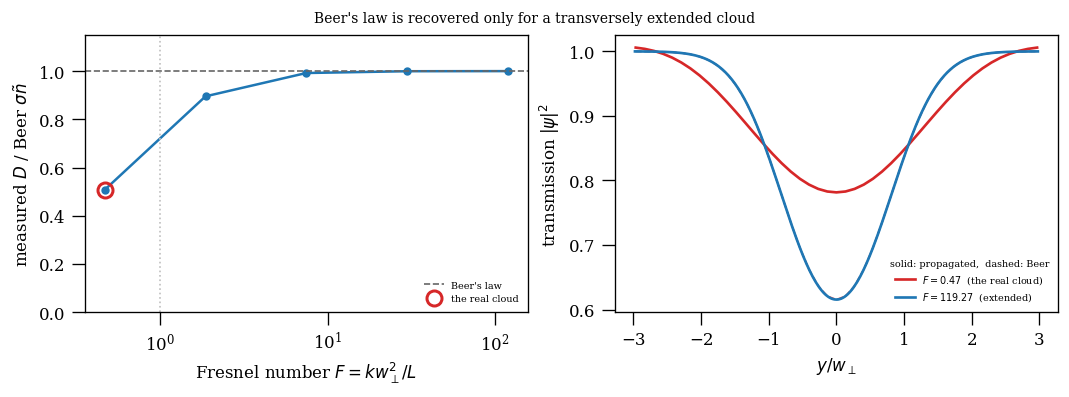

In [19]:
fig, _ = iplt.plot_beer_limit(F_list, ratio_list, profiles=profiles,
    mark=(F_actual, ratio_list[0], "the real cloud"),
    title="Beer's law is recovered only for a transversely extended cloud")
plt.show()

## 7. Phase contrast reads spin imbalance

Scanning $\xi$ at fixed density. The thin-screen phase is exactly linear in $\xi$;
the propagated one is not, and the phase-contrast signal is worse still — it can
stop being monotonic, so a measured signal maps back onto two imbalances.

The shaded band is $\pm 1/\sqrt{N}$: projection noise. That is where a real
measurement lives, and it is comfortably inside the linear regime even though the
fully polarized cloud is far outside it.

In [20]:
scan_prop = Propagator.for_cloud(response, cloud, n_grid=384, n_slices=120)
xi_scan = np.linspace(-1., 1., 13)
xi_scan, sig_scan, phase_scan, D_scan = readout.imbalance_curve(
    scan_prop,
    lambda xi: UniformMixture(cloud, response, probe.species(xi)),
    xi_scan, NA=NA, s0_incident=probe.s0_incident)

print(f"{'xi':>7} {'thin phi':>10} {'BPM phi':>10} {'on-axis D':>11} {'PCI signal':>11}")
for x, p_, d_, s_ in zip(xi_scan, phase_scan, D_scan, sig_scan):
    print(f"{x:7.3f} {x*phi:10.3f} {p_:10.3f} {d_:11.3f} {s_:11.3f}")

lin = np.abs(xi_scan) < 0.2
slope = np.polyfit(xi_scan[lin], sig_scan[lin], 1)[0]
xi_sn = 1/np.sqrt(N_ATOMS)
print(f"\nTrue optical depth is spin-blind (thin screen D = {D:.3f} at every xi),")
print(f"but the MEASURED on-axis D swings {D_scan.min():+.3f} to {D_scan.max():+.3f}:")
print("the lens redistributes light on axis faster than the atoms remove it, so an")
print("atom number read off absorption is spin-contaminated.")
print(f"\nPCI response near balance: dS/dxi = {slope:+.3f}")
print(f"  -> a 1/sqrt(N) = {xi_sn:.4f} imbalance gives {abs(slope)*xi_sn:.4f} rms of signal")
if not np.all(np.diff(sig_scan) > 0):
    t = int(np.argmin(sig_scan))
    print(f"  NOT MONOTONIC: turns at xi = {xi_scan[t]:+.2f} and folds back")

     xi   thin phi    BPM phi   on-axis D  PCI signal
 -1.000     -4.459     -1.694       0.618      -0.267
 -0.833     -3.716     -1.476       0.450      -0.482
 -0.667     -2.973     -1.235       0.330      -0.660
 -0.500     -2.230     -0.971       0.256      -0.756
 -0.333     -1.486     -0.681       0.223      -0.713
 -0.167     -0.743     -0.360       0.225      -0.474
  0.000      0.000     -0.002       0.247       0.007
  0.167      0.743      0.396       0.265       0.751
  0.333      1.486      0.832       0.247       1.741
  0.500      2.230      1.292       0.159       2.916
  0.667      2.973      1.754      -0.011       4.166
  0.833      3.716      2.196      -0.244       5.344
  1.000      4.459      2.607      -0.506       6.285

True optical depth is spin-blind (thin screen D = 0.486 at every xi),
but the MEASURED on-axis D swings -0.506 to +0.618:
the lens redistributes light on axis faster than the atoms remove it, so an
atom number read off absorption is spin-conta

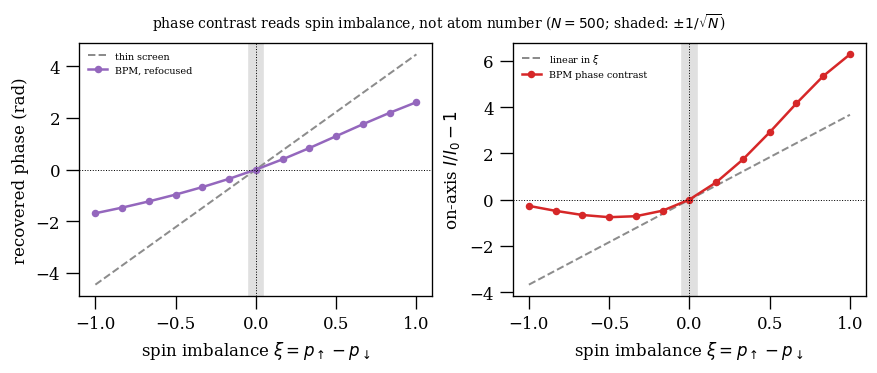

In [21]:
fig, _ = iplt.plot_imbalance_scan(xi_scan, sig_scan, phase=phase_scan,
                                  thin_screen_phase=phi, N_atoms=N_ATOMS)
fig.suptitle(rf"phase contrast reads spin imbalance, not atom number "
             rf"($N={N_ATOMS:.0f}$; shaded: $\pm 1/\sqrt{{N}}$)", fontsize='small')
plt.show()

---

# Part II — putting a spin state on the cloud

Everything above treated the spin composition as one number for the whole cloud.
Now give every voxel its own spin.

## 8. The spin field

`SpinField` holds a mean spin vector per voxel of the propagation grid — the
propagator's own axial slices, and a transverse window cropped to where the cloud
actually is, so registration with the optics is exact and no interpolation happens
anywhere.

**Why 3D and not a map of columns.** A $z$-rotation commutes with $S_z$, so the
light shift writes into the *phase*, not the populations. But the local intensity
varies along the probe, so that phase is a genuinely three-dimensional grating —
and a closing $\pi/2$ pulse converts it into a three-dimensional *population*
grating. Averaging over columns first would destroy exactly the structure the
propagation exists to resolve.

In [22]:
geom = SpinGeometry.from_propagator(prop, cloud)
print(geom)
print(f"voxels: {np.prod(geom.shape):,}   peak column atom number: "
      f"{geom.column_atom_number.max():.2f}")

field = SpinField.spin_coherent(geom, Sz_total=1.0)   # all |up>
print()
print(field.summary())

SpinGeometry(180 slices x 89^2, window +-2.06 um)
voxels: 1,425,780   peak column atom number: 1.29

SpinField over SpinGeometry(180 slices x 89^2, window +-2.06 um)
  <s> = (+0.0000, +0.0000, +0.5000)   Sz_total = +1.0000
  cloud-integrated contrast = 0.0000
  local coherence: mean 0.0000, min 0.0000, max 0.0000
  column xi in [+1.0000, +1.0000], |Z_col| in [0.0000, 0.0000]


### The invariance that shapes the whole API

Rotate every spin about $z$ by an arbitrary amount and re-image: the picture is
**bit-for-bit identical**. The susceptibility depends only on $S_z$, and a
$z$-rotation cannot move it. So "imprint a phase, then image again" measures
nothing — which is why the module exposes sequences.

In [23]:
check = SpinField.spin_coherent(geom, Sz_total=0.3)
before = prop.propagate(check.susceptibility_source(response, probe),
                        s0_incident=probe.s0_incident)
check.rotate_z(np.random.default_rng(0).uniform(-np.pi, np.pi, geom.shape))
after = prop.propagate(check.susceptibility_source(response, probe),
                       s0_incident=probe.s0_incident)
print(f"max |psi_after - psi_before| after a random 3D z-rotation = "
      f"{np.abs(after.psi_exit - before.psi_exit).max():.3e}")
print(f"Sz unchanged to {np.abs(check.Sz_total - 0.3):.2e}")

max |psi_after - psi_before| after a random 3D z-rotation = 0.000e+00
Sz unchanged to 5.55e-17


## 9. What one imaging pulse does to the spins

A single propagation pass supplies all three effects, because they all follow from
the same local intensity:

- the **image**;
- a $z$-rotation $\phi_z(r) = 2\pi\,\nu_{\rm diff}(r)\,t$ from the differential light shift;
- **decoherence** $e^{-N_{\rm sc}(r)}$ from spontaneous scattering. The two
  transitions are split by far more than a linewidth, so a scattered photon is
  which-path information and each one destroys coherence.

In [24]:
t_pulse = 5.0e-6
balanced = SpinField.spin_coherent(geom, Sz_total=1.0)
balanced.rotate_y(np.pi/2)            # the pi/2 that creates the superposition
print(f"after pi/2:  Sz = {balanced.Sz_total:+.4f}, contrast = {balanced.contrast:.4f}")

one = Sequence([ImagePulse(prop, t_pulse=t_pulse, NA=NA)]).run(balanced, probe=probe)
r1 = one[0]
print()
print(r1.summary())
print(f"\ncontrast {balanced.contrast:.4f} -> {one.final_contrast:.4f}, "
      f"Sz stays {one.final_Sz:+.2e}  (a z-rotation cannot move it)")

after pi/2:  Sz = +0.0000, contrast = 1.0000



ImagingResult  t_pulse = 5.00 us
  recovered phase = -0.0020 rad,  on-axis D = +0.2465
  PCI signal I/I0 - 1 = +0.0070   (image range [0.999, 1.007])
  coherent into NA = 0.98459
  peak local s = 0.3448, <I>/I0 = 0.9302
  imprinted |phi_z|: peak 1.765 rad, column-mean peak 1.736 rad
  differential light shift (dn - up): mean +51.216 kHz, peak +56.186 kHz
  within-column phase spread: peak 0.063 rad -> min coherence 0.998
  photons scattered per atom = 0.0877  -> coherence x 0.916

contrast 1.0000 -> 0.9143, Sz stays +6.12e-17  (a z-rotation cannot move it)


In [ ]:
fig, _ = splt.plot_phase_grating(r1, geom,
    waist=TWEEZER_WAIST, n_waists=N_WAISTS,
    title="what the imaging pulse writes into the spins")
plt.show()

Note how *gentle* the grating is — roughly 15% across the cloud. That is a
consequence of imaging the **balanced** state: with $\mathrm{Re}\,\alpha$ cancelled
the cloud is a pure absorber, so the intensity an atom sees varies only through
absorption, not lensing. A polarized cloud at the same detuning concentrates the
probe several-fold and would imprint a much steeper grating. The mildness here is
what lets the sequence keep its contrast.

In [26]:
pol = SpinField.spin_coherent(geom, Sz_total=1.0)
one_pol = Sequence([ImagePulse(prop, t_pulse=t_pulse, NA=NA, back_action=False)]
                   ).run(pol, probe=probe)
rp = one_pol[0]
print(f"{'state':10s} {'<I>/I0':>8s} {'s_peak':>8s} {'phi_z range (rad)':>22s} "
      f"{'photons/atom':>13s}")
for nm, r_ in (("balanced", r1), ("polarized", rp)):
    m = np.abs(r_.phi_z)
    print(f"{nm:10s} {r_.propagation.mean_intensity:8.3f} {r_.propagation.s_peak:8.3f} "
          f"{m.min():10.3f} - {m.max():<9.3f} {r_.photons_per_atom:13.4f}")
print("\nThe polarized cloud lenses, so it imprints a steeper grating on itself"
      "\nand scatters more -- but it has no coherence left to lose.")

state        <I>/I0   s_peak      phi_z range (rad)  photons/atom
balanced      0.930    0.345      1.509 - 1.765            0.0877
polarized     1.810    1.942      0.385 - 9.893            0.1703

The polarized cloud lenses, so it imprints a steeper grating on itself
and scatters more -- but it has no coherence left to lose.


## 10. The Ramsey sequence

$\pi/2 \to$ image $\to \pi/2 \to$ image.

The first pulse sees a balanced cloud — almost no refractive signal, by design —
but imprints $\phi_z(r)$. The closing $\pi/2$ maps that phase onto population,
$S_z(r) = -\tfrac{1}{2}C(r)\cos\phi_z(r)$, and only then does a probe see spatial
structure. The first image is the disturbance; the second is the measurement.

In [27]:
initial = SpinField.spin_coherent(geom, Sz_total=1.0)     # start POLARIZED
out = ramsey(prop, t_pulse=t_pulse, NA=NA).run(initial, probe=probe)
print(out.summary())
print(f"\nsignal ratio image2/image1 = {abs(out[1].signal/out[0].signal):.1f}x")

SequenceResult  4 operations, 2 images
  rotate +0.500 pi about y
  ImagingResult  t_pulse = 5.00 us
    recovered phase = -0.0020 rad,  on-axis D = +0.2465
    PCI signal I/I0 - 1 = +0.0070   (image range [0.999, 1.007])
    coherent into NA = 0.98459
    peak local s = 0.3448, <I>/I0 = 0.9302
    imprinted |phi_z|: peak 1.765 rad, column-mean peak 1.736 rad
    differential light shift (dn - up): mean +51.216 kHz, peak +56.186 kHz
    within-column phase spread: peak 0.063 rad -> min coherence 0.998
    photons scattered per atom = 0.0877  -> coherence x 0.916
  rotate +0.500 pi about y
  ImagingResult  t_pulse = 5.00 us
    recovered phase = +0.0180 rad,  on-axis D = +0.0914
    PCI signal I/I0 - 1 = +0.0796   (image range [0.994, 1.080])
    coherent into NA = 0.94732
    peak local s = 0.3440, <I>/I0 = 0.9675
    imprinted |phi_z|: peak 1.761 rad, column-mean peak 1.734 rad
    differential light shift (dn - up): mean +53.267 kHz, peak +56.044 kHz
    within-column phase spread: p

In [ ]:
fig, _ = splt.plot_sequence_images(out, prop.grid,
    waist=TWEEZER_WAIST, n_waists=N_WAISTS,
    labels=["image 1 (balanced cloud)", "image 2 (after closing $\pi/2$)"],
    title="the imprint is invisible to the pulse that made it")
plt.show()

fig, _ = splt.plot_spin_columns(out.field,
    waist=TWEEZER_WAIST, n_waists=N_WAISTS,
    title="spin state after the sequence: phase has become population")
plt.show()

### Where the contrast went

Two independent channels, and the model separates them: inhomogeneous dephasing
(different voxels precess by different amounts, so the transverse spins no longer
add) and spontaneous scattering (which-path information). The first is recoverable
by an echo; the second is not.

In [29]:
tot_photons = sum(r.photons_per_atom for r in out.images)
print(f"contrast {out.initial_contrast:.4f} -> {out.final_contrast:.4f}")
print(f"  spontaneous scattering: {tot_photons:.4f} photons/atom over both pulses")
print(f"    -> coherence x exp(-N_sc) = {np.exp(-tot_photons):.4f}")
print(f"  within-column dephasing: min |<exp(i phi)>| = "
      f"{out[0].dephasing_factor.min():.4f}")
print(f"  the rest is the cos(phi_z) structure itself, which is signal, not loss")

contrast 0.0000 -> 0.8332
  spontaneous scattering: 0.1788 photons/atom over both pulses
    -> coherence x exp(-N_sc) = 0.8362
  within-column dephasing: min |<exp(i phi)>| = 0.9980
  the rest is the cos(phi_z) structure itself, which is signal, not loss


## 10b. The same sequence from other spin-coherent states

Repeating the Ramsey sequence from a range of initial imbalances, including the
$\sqrt{1/4}$ / $\sqrt{3/4}$ amplitude states ($\xi_0 = \mp 1/2$).

The opening $\pi/2$ rotates whatever it is handed. A state prepared at $\xi_0$ lands
at $\xi = -\sqrt{1-\xi_0^2}$, so only a **polarized** start reaches the equator; the
$\xi_0 = \pm 1/2$ states land at $\xi = -0.87$, nearly polarized in
$|\downarrow\rangle$.

That has a consequence worth reading off the table. A cloud polarized towards
$|\downarrow\rangle$ is a *diverging* lens: it expels the probe, dropping the mean
intensity its own atoms see to $\langle I\rangle/I_0 = 0.50$ against $0.93$ for the
balanced case. The differential light shift is linear in local intensity, so it
halves too — **26 kHz instead of 51 kHz**. The AC Stark shift an atom feels is not a
property of the beam alone; it depends on the spin state of the cloud the atom is
sitting inside. This is the same lensing asymmetry that makes the shift non-even in
the probe offset, appearing here as a function of spin instead.

Note also that $\xi_0 = +1/2$ and $\xi_0 = -1/2$ give an *identical* first image —
after the $\pi/2$ they are the same optical state — but different second images,
because they differ in a transverse phase the first image cannot see.

In [30]:
print(f"{'amplitudes (up, dn)':>26} {'xi_0':>6} {'xi after':>9} {'<I>/I0':>8} "
      f"{'shift kHz':>10} {'signal 1':>10} {'signal 2':>10} {'contrast':>9}")
rows = []
for a_up in (1.0, 0.75, 0.5, 0.25, 0.0):
    xi0 = 2*a_up - 1.0                       # p_up = a_up
    lbl = f"(sqrt({a_up:.2f}), sqrt({1-a_up:.2f}))"
    start = SpinField.spin_coherent(geom, Sz_total=xi0)
    after = start.copy().rotate_y(np.pi/2)
    o = ramsey(prop, t_pulse=t_pulse, NA=NA).run(start, probe=probe)
    rows.append((lbl, xi0, after.Sz_total, o))
    print(f"{lbl:>26} {xi0:+6.2f} {after.Sz_total:+9.3f} "
          f"{o[0].propagation.mean_intensity:8.3f} "
          f"{o[0].mean_light_shift_Hz/1e3:+10.2f} "
          f"{o[0].signal:+10.4f} {o[1].signal:+10.4f} {o.final_contrast:9.4f}")

print("\nThe light shift is NOT a property of the beam alone: it follows the")
print("local intensity, and the cloud's own lensing sets that.  Rows landing near the")
print("|dn> pole after the pi/2 diverge the probe, expelling it (<I>/I0 = 0.50 vs 0.93)")
print("and halving the shift those atoms feel.  Rows +0.50 and -0.50 share a first")
print("image -- the same optical state -- but differ in the second, through a")
print("transverse phase the first image is blind to.")

       amplitudes (up, dn)   xi_0  xi after   <I>/I0  shift kHz   signal 1   signal 2  contrast


  (sqrt(1.00), sqrt(0.00))  +1.00    +0.000    0.930     +51.22    +0.0070    +0.0796    0.8332


  (sqrt(0.75), sqrt(0.25))  +0.50    -0.866    0.500     +27.53    -0.4414    -0.7586    0.8389


  (sqrt(0.50), sqrt(0.50))  +0.00    -1.000    0.462     +25.45    -0.2669    +0.0070    0.9143


  (sqrt(0.25), sqrt(0.75))  -0.50    -0.866    0.500     +27.53    -0.4414    +1.6831    0.7920


  (sqrt(0.00), sqrt(1.00))  -1.00    -0.000    0.930     +51.22    +0.0070    -0.0539    0.8362

The light shift is NOT a property of the beam alone: it follows the
local intensity, and the cloud's own lensing sets that.  Rows landing near the
|dn> pole after the pi/2 diverge the probe, expelling it (<I>/I0 = 0.50 vs 0.93)
and halving the shift those atoms feel.  Rows +0.50 and -0.50 share a first
image -- the same optical state -- but differ in the second, through a
transverse phase the first image is blind to.


## 11. A Ramsey fringe

Scanning the hold detuning rotates every spin about $z$ by a uniform angle before
the closing $\pi/2$, turning the imprint into a fringe. This is the observable the
whole model exists to predict.

In [31]:
from kamo.spin import FreeEvolve

fringe_prop = Propagator.for_cloud(response, cloud, n_grid=384, n_slices=120)
fringe_geom = SpinGeometry.from_propagator(fringe_prop, cloud)
hold = 50.0e-6
# One full fringe spans 1/hold = 20 kHz.  Sample it properly: 6 kHz steps would
# advance the phase by 1.9 rad each and alias the fringe into noise.
fringe_span = 1.0 / hold
detunings = np.linspace(-0.5 * fringe_span, 0.5 * fringe_span, 15)
print(f"one fringe = 1/hold = {fringe_span/1e3:.1f} kHz;  "
      f"{np.degrees(2*np.pi*(detunings[1]-detunings[0])*hold):.0f} deg per step")

sig, con = [], []
for d in detunings:
    seq = Sequence([Rotate(np.pi/2, 'y'),
                    ImagePulse(fringe_prop, t_pulse=t_pulse, NA=NA),
                    FreeEvolve(hold, detuning_Hz=float(d)),
                    Rotate(np.pi/2, 'y'),
                    ImagePulse(fringe_prop, t_pulse=t_pulse, NA=NA)])
    o = seq.run(SpinField.spin_coherent(fringe_geom, 1.0), probe=probe)
    sig.append(o[1].signal); con.append(o.final_contrast)
sig, con = np.array(sig), np.array(con)

for d, s_, c_ in zip(detunings, sig, con):
    print(f"  detuning {d/1e3:+7.1f} kHz -> signal {s_:+.4f}, contrast {c_:.4f}")

one fringe = 1/hold = 20.0 kHz;  26 deg per step


  detuning   -10.0 kHz -> signal -0.0591, contrast 0.8360
  detuning    -8.6 kHz -> signal +2.0169, contrast 0.6552
  detuning    -7.1 kHz -> signal +4.3787, contrast 0.3195
  detuning    -5.7 kHz -> signal +5.6508, contrast 0.1281
  detuning    -4.3 kHz -> signal +5.7547, contrast 0.0553
  detuning    -2.9 kHz -> signal +4.6641, contrast 0.2418
  detuning    -1.4 kHz -> signal +2.3364, contrast 0.5986
  detuning    +0.0 kHz -> signal +0.0855, contrast 0.8331
  detuning    +1.4 kHz -> signal -0.7653, contrast 0.7270
  detuning    +2.9 kHz -> signal -0.6558, contrast 0.4917
  detuning    +4.3 kHz -> signal -0.4289, contrast 0.1916
  detuning    +5.7 kHz -> signal -0.3963, contrast 0.1438
  detuning    +7.1 kHz -> signal -0.5778, contrast 0.4513
  detuning    +8.6 kHz -> signal -0.7285, contrast 0.7004
  detuning   +10.0 kHz -> signal -0.0591, contrast 0.8360


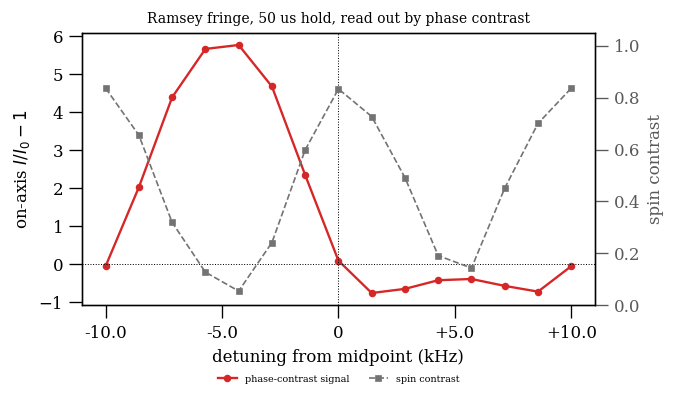

In [32]:
fig, _ = splt.plot_ramsey_fringe(detunings, sig, contrast=con,
    title=f"Ramsey fringe, {hold*1e6:.0f} us hold, read out by phase contrast")
plt.show()

## 12. Shot noise

A real balanced state is not exactly balanced: with $N$ independent atoms the
imbalance fluctuates by $1/\sqrt{N}$, drawn independently per column. That scatter
*is* the signal a dispersive spin measurement sees — there is no mean phase to read
at the midpoint, only its shot-to-shot variance.

The noise is drawn on cells sized to hold ~10 atoms rather than per pixel. That is
not a numerical detail: on a fine grid a pixel column holds about one atom, so a
Gaussian that wide, clipped to the physical range of $\xi$, would suppress the
variance — by an amount that changed with the optical grid resolution.

In [33]:
rng = np.random.default_rng(12345)
base = SpinField.spin_coherent(fringe_geom, Sz_total=0.0)

# The noise is drawn on cells holding ~10 atoms, not on pixels: at this grid a
# pixel column holds order one atom, and a Gaussian that wide, clipped to the
# physical range of xi, would suppress the variance by a GRID-DEPENDENT amount.
print(f"noise cell = {base.noise_block_size()} px "
      f"(peak column holds {fringe_geom.column_atom_number.max():.2f} atoms)")

drawn = np.array([base.sample_shot(rng).Sz_total for _ in range(2000)])
print(f"expected xi_rms = 1/sqrt(N)   = {1/np.sqrt(N_ATOMS):.4f}")
print(f"realized xi_rms (2000 draws)  = {drawn.std():.4f}")

shots = []
for _ in range(12):
    sh = base.sample_shot(rng)
    o = Sequence([ImagePulse(fringe_prop, t_pulse=t_pulse, NA=NA,
                             back_action=False)]).run(sh, probe=probe)
    shots.append((sh.Sz_total, o[0].signal))
shots = np.array(shots)
print(f"12 propagated shots: xi rms = {shots[:,0].std():.4f}, "
      f"PCI signal rms = {shots[:,1].std():.5f}")
print(f"implied dS/dxi = {np.polyfit(shots[:,0], shots[:,1], 1)[0]:+.3f}"
      f"   (the xi scan above gave {slope:+.3f})")

noise cell = 3 px (peak column holds 5.14 atoms)


expected xi_rms = 1/sqrt(N)   = 0.0447
realized xi_rms (2000 draws)  = 0.0446


12 propagated shots: xi rms = 0.0515, PCI signal rms = 0.18992
implied dS/dxi = +3.591   (the xi scan above gave +3.673)


## 13. What this model does and does not include

Included: the exact angular-spectrum propagator (not paraxial); the full complex
polarizability with saturation on both quadratures; the local saturation parameter
from the propagated field; depth-of-field loss through an honest refocus;
nonlinear and non-monotonic phase-contrast response; three-dimensional spin
structure; inhomogeneous dephasing separated from spontaneous-scattering
decoherence.

Not included, roughly in order of size:

- **Lorentz–Lorenz local fields**, $\sim 9\%$ here. Available as a flag —
  `TwoLevelResponse(..., local_field=True)` — so it can be bounded rather than
  only cited. Recurrent scattering beyond mean-field LL is unbounded at
  $n\lambda^3 \approx 62$ and is the largest uncontrolled approximation.
- **Ground-state $m_j$ admixture**, $\sim 2.5\%$ at this field. For the exact
  multi-level shift use `AtomicStructure.laser_sweep`.
- **Optical pumping.** Scattering decoheres here but does not repopulate, so
  $S_z$ is conserved through a pulse.
- **Inelastic scattering.** Only the coherent field propagates; at local $s\sim 2$
  the elastic fraction is $1/(1+s)$.
- **Density response.** One shared profile; spin weights the polarizability but
  does not reshape the cloud.
- **Quantum correlations.** Mean-field Bloch vectors, so no spin squeezing;
  projection noise enters stochastically via `sample_shot`.

In [34]:
print("Lorentz-Lorenz sensitivity check: how much does the 9% correction move things?")
from kamo.imaging import TwoLevelResponse
ll = TwoLevelResponse(response.wavelength, response.linewidth_Hz,
                      sigma0=response.sigma0, local_field=True)
for name, r_ in (("independent atoms", response), ("Lorentz-Lorenz", ll)):
    D_, p_ = r_.thin_screen(cloud.peak_column_density, probe.species(1.0))
    pr = Propagator.for_cloud(r_, cloud, n_grid=384, n_slices=120)
    rr = pr.propagate(UniformMixture(cloud, r_, probe.species(1.0)),
                      s0_incident=probe.s0_incident)
    ps = readout.refocus(rr)
    print(f"  {name:20s} thin D={D_:.4f} phi={p_:+.3f}   "
          f"BPM phi={readout.recovered_phase(ps, rr.grid):+.3f}  "
          f"s_peak={rr.s_peak:.3f}")

Lorentz-Lorenz sensitivity check: how much does the 9% correction move things?


  independent atoms    thin D=0.4859 phi=+4.459   BPM phi=+2.607  s_peak=1.943


  Lorentz-Lorenz       thin D=0.4859 phi=+4.459   BPM phi=+2.642  s_peak=1.964
